800 1280


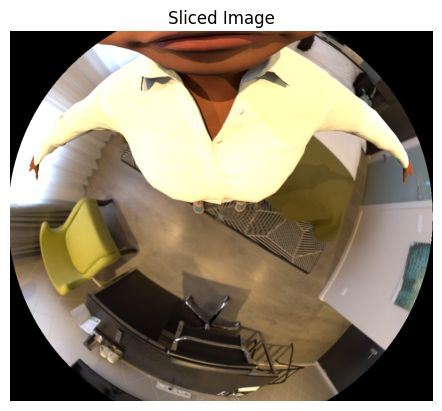

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 파일 경로 설정
image_path = r'F:\xr_egopose_dataset_small\TrainSet\female_001_a_a\env_001\cam_down\rgba\female_001_a_a.rgba.000001.png'  # 여기에 이미지 파일 경로를 넣어주세요.

# OpenCV를 사용하여 이미지 열기
image = cv2.imread(image_path)

# BGR 형식을 RGB 형식으로 변환 (OpenCV는 기본적으로 BGR 형식으로 이미지를 읽음)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 이미지 크기 확인
height, width, _ = image.shape
print(height, width)

# 슬라이싱에 사용할 bbox 설정
bbox = np.array([200, 0, width-165, height])  # 

# bbox를 사용하여 이미지 슬라이싱
sliced_image = image_rgb[bbox[1]:bbox[3], bbox[0]:bbox[2]]

# 슬라이싱된 이미지 출력
plt.imshow(sliced_image)
plt.axis('off')  # 축 숨기기
plt.title('Sliced Image')
plt.show()

In [7]:
import os
from PIL import Image

# TrainSet 디렉토리 경로 설정
trainset_dir = r"F:\xr_egopose_dataset_small\TrainSet"

# TrainSet 디렉토리 내부의 각 세트 폴더 순회
for set_name in os.listdir(trainset_dir):
    set_path = os.path.join(trainset_dir, set_name)
    if os.path.isdir(set_path):
        # 세트 폴더 내의 환경(env) 폴더 순회
        for env_folder in os.listdir(set_path):
            env_path = os.path.join(set_path, env_folder)
            cam_down_path = os.path.join(env_path, 'cam_down')
            
            if os.path.isdir(cam_down_path):
                rgba_folder = os.path.join(cam_down_path, 'rgba')
                
                if os.path.exists(rgba_folder):
                    # rgba 폴더 내의 이미지 순회
                    for image_name in os.listdir(rgba_folder):
                        image_path = os.path.join(rgba_folder, image_name)
                        
                        try:
                            with Image.open(image_path) as img:
                                # 이미지 자르기 [200, 0, 1280-165, 800]
                                cropped_img = img.crop((200, 0, 1280-165, 800))
                                
                                # 자른 이미지를 256x256 크기로 리사이즈
                                resized_img = cropped_img.resize((256, 256))
                                
                                # 기존 파일에 덮어쓰기
                                resized_img.save(image_path)
                        except Exception as e:
                            print(f"{image_name} 처리 중 오류 발생: {e}")

: 